In [1]:
import numpy as np
import pandas as pd
from math import e
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
data = {
    'temperature': [10, 15, 20, 25, 30, 35],
    'humidity':    [30, 40, 50, 60, 70, 80],
    'y':           [ 0,  0,  1,  1,  1,  0]
}
df = pd.DataFrame(data)
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,20,50,1
3,25,60,1
4,30,70,1
5,35,80,0


In [3]:
mask0 = df['y'] == 0
mask1 = df['y'] == 1

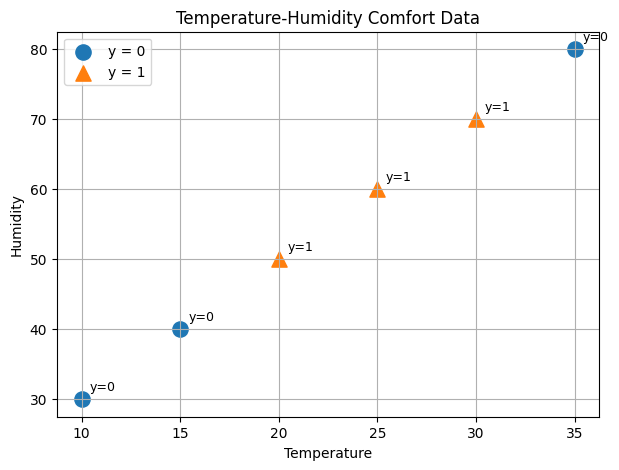

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(df.loc[mask0, 'temperature'], df.loc[mask0, 'humidity'], marker='o', s=120, label='y = 0')
plt.scatter(df.loc[mask1, 'temperature'], df.loc[mask1, 'humidity'], marker='^', s=120, label='y = 1')

for temp, hum, yv in zip(df['temperature'], df['humidity'], df['y']):
    plt.annotate(f'y={yv}', (temp, hum), textcoords='offset points', xytext=(6, 6), fontsize=9)

plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('Temperature-Humidity Comfort Data')
plt.legend()
plt.grid(True)

In [ ]:
#  입력값 numpy배열로 만들기 (n, 2)
X_raw = df[['temperature', 'humidity']].to_numpy(dtype=float)
# 정답도 계산에 맞도록 (n, 1) 세로벡터로 만들기
y = df['y'].to_numpy(dtype=float).reshape(-1, 1)
X_raw, y

(array([[10., 30.],
        [15., 40.],
        [20., 50.],
        [25., 60.],
        [30., 70.],
        [35., 80.]]),
 array([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.]]))

In [8]:
# axis=0: 열방향 계산. 컬럼별 평균
X_mean = X_raw.mean(axis=0, keepdims=True)
X_std = X_raw.std(axis=0, keepdims=True)
X_mean, X_std

(array([[22.5, 55. ]]), array([[ 8.53912564, 17.07825128]]))

In [9]:
# 서로다른 단위. -> 정규화 필요
X_norm = (X_raw - X_mean) / X_std
X_raw.shape, y.shape, X_norm.shape

((6, 2), (6, 1), (6, 2))

In [10]:
df['temperature_norm'] = X_norm[:, 0]
df['humidity_norm'] = X_norm[:, 1]
df

,temperature,humidity,y,temperature_norm,humidity_norm
0,10,30,0,-1.46385,-1.46385
1,15,40,0,-0.87831,-0.87831
2,20,50,1,-0.29277,-0.29277
3,25,60,1,0.29277,0.29277
4,30,70,1,0.87831,0.87831
5,35,80,0,1.46385,1.46385


In [ ]:
def sigmoid(H):
    # 너무크거나 작은값 자르기
    H_clip = np.clip(H, -500, 500)
    z = 1.0 / (1.0 + e **(-H_clip))
    return z

In [12]:
def bce_cost(y, z):
    epsilon = 1e-7
    # z범위 제한해서 log계산 안정적으로 만들기
    z_clip = np.clip(z, epsilon, 1.0 - epsilon)
    # bce 계산
    cost = -(y * np.log(z_clip) + (1.0 - y) * np.log(1.0 - z_clip))
    return np.mean(cost)

In [13]:
X1_norm = X_norm[:, [0]]
X2_norm = X_norm[:, [1]]

In [15]:
# np.random.randn()은 평균 0, 표준편차 1 의 정규분포난수를 만듬.
# 난수에 0.1을 곱하는 이유는 처음부터 가중치가 너무 크면 sigmoid출력이 0 또는 1에 너무 가까이 붙어버려 
# 학습이 잘 진행되지 않을 수 있기 때문.

# 히든뉴런 1 가중치
a11 = np.random.randn() * 0.1 # 온도
a12 = np.random.randn() * 0.1 # 습도
b1 = 0.0
# 히든뉴런 2 가중치
a21 = np.random.randn() * 0.1
a22 = np.random.randn() * 0.1
b2 = 0.0
# 출력층
a31 = np.random.randn() * 0.1
a32 = np.random.randn() * 0.1
b3 = 0.0

In [16]:
# 초기 파라미터
param_table = pd.DataFrame({
    'name':    ['a11', 'a12', 'b1', 'a21', 'a22', 'b2', 'a31', 'a32', 'b3'],
    'value':   [round(v, 4) for v in [a11, a12, b1, a21, a22, b2, a31, a32, b3]],
    'meaning': [
        'X1(온도) -> 히든 뉴런 1 가중치',
        'X2(습도) -> 히든 뉴런 1 가중치',
        '히든 뉴런 1 편향',
        'X2(온도) -> 히든 뉴런 2 가중치',
        'X2(습도) -> 히든 뉴런 2 가중치',
        '히든 뉴런 1 편향',
        'z_hidden_1 -> 출력층 가중치',
        'z_hidden_2 -> 출력층 가중치',
        '출력층 편향'
    ]
})
param_table

,name,value,meaning
0,a11,0.1579,X1(온도) -> 히든 뉴런 1 가중치
1,a12,0.0767,X2(습도) -> 히든 뉴런 1 가중치
2,b1,0.0000,히든 뉴런 1 편향
3,a21,-0.0469,X2(온도) -> 히든 뉴런 2 가중치
4,a22,0.0543,X2(습도) -> 히든 뉴런 2 가중치
5,b2,0.0000,히든 뉴런 1 편향
6,a31,-0.0463,z_hidden_1 -> 출력층 가중치
7,a32,-0.0466,z_hidden_2 -> 출력층 가중치
8,b3,0.0000,출력층 편향


In [ ]:
def mlp_forward_textbook_style(
        X1, X2, a11, a12, b1, a21, a22, b2, a31, a32, b3
):
    # 현재 파라미터로 예측확률 계산하는 순전파 함수
    # X1, X2는 원본이 아니라 (n,1) 세로벡터로 만든 정규화된 온도, 습도
    # 반환값 요약:
    # H_hidden_1, H_hidden_2, H_output -> sigmoid 이전의 선형 계산값
    # z_hidden_1, z_hidden_2: 중간 출력값
    # z_output -> 최종 예측 확률

    # --- 히든 뉴런 1 ---
    H_hidden_1 = a11 * X1 + a12 * X2 + b1
    z_hidden_1 = sigmoid(H_hidden_1)

    # --- 히든 뉴런 2 ---
    H_hidden_2 = a21 * X1 + a22 * X2 + b2
    z_hidden_2 = sigmoid(H_hidden_2)

    # --- 출력층 ---
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2
    z_output = sigmoid(H_output)

    return H_hidden_1, z_hidden_1, H_hidden_2, z_hidden_2, H_output, z_output
